# 01 — The Quantum Threat: From Qubits to Shor's Algorithm

## Week 1: Qiskit Basics and the Bell State Experiment

**Goal**: Verify our quantum computing setup, build a Bell state circuit, and observe entanglement on a simulator.

This notebook will grow over Weeks 1–7 as we build toward Shor's algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print(f"Qiskit setup OK")

Qiskit setup OK


## 1.1 Single-Qubit Gates: X and H

Before building the Bell state, let's see what individual gates do.

**X gate** (Pauli-X / NOT): flips |0> to |1> and vice versa.

**H gate** (Hadamard): puts a qubit into equal superposition.

X gate on |0>: {'1': 1024}
Expected: always |1>


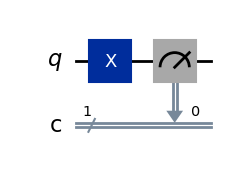

In [2]:
# X gate: flip |0> to |1>
qc_x = QuantumCircuit(1, 1)  # 1 qubit, 1 classical bit
qc_x.x(0)                    # apply X gate to qubit 0
qc_x.measure(0, 0)           # measure qubit 0 into classical bit 0

sim = AerSimulator()
result = sim.run(qc_x, shots=1024).result()
counts = result.get_counts()
print(f"X gate on |0>: {counts}")
print("Expected: always |1>")
qc_x.draw('mpl')

H gate on |0>: {'0': 501, '1': 523}
Expected: ~50% |0>, ~50% |1>


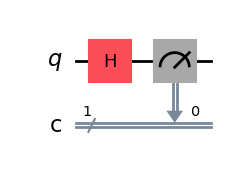

In [3]:
# H gate: superposition
qc_h = QuantumCircuit(1, 1)
qc_h.h(0)                    # apply Hadamard to qubit 0
qc_h.measure(0, 0)

result = sim.run(qc_h, shots=1024).result()
counts = result.get_counts()
print(f"H gate on |0>: {counts}")
print("Expected: ~50% |0>, ~50% |1>")
qc_h.draw('mpl')

## 1.2 The Bell State Circuit

Now we build the simplest entangled state: |Phi+> = (|00> + |11>) / sqrt(2)

The circuit:
1. Start with |00> (both qubits in ground state)
2. Apply H to qubit 0 → (|0> + |1>)/sqrt(2) tensor |0> = (|00> + |10>)/sqrt(2)
3. Apply CNOT (qubit 0 controls, qubit 1 target) → (|00> + |11>)/sqrt(2)

The CNOT correlates the two qubits without collapsing the superposition.

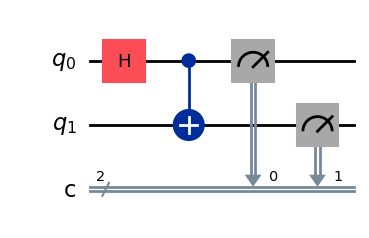

In [4]:
# Build the Bell state circuit
bell = QuantumCircuit(2, 2)   # 2 qubits, 2 classical bits
bell.h(0)                     # step 1: superposition on qubit 0
bell.cx(0, 1)                 # step 2: CNOT — entangle qubit 0 and 1
bell.measure([0, 1], [0, 1])  # measure both qubits

bell.draw('mpl')

In [5]:
# Run on simulator with 4096 shots for good statistics
result = sim.run(bell, shots=4096).result()
counts = result.get_counts()

print(f"Bell state measurement results: {counts}")
print(f"\nExpected: ~50% '00', ~50% '11', zero '01' and '10'")
print(f"\nActual fractions:")
for outcome, count in sorted(counts.items()):
    print(f"  |{outcome}>: {count}/4096 = {count/4096:.3f}")

Bell state measurement results: {'11': 2110, '00': 1986}

Expected: ~50% '00', ~50% '11', zero '01' and '10'

Actual fractions:
  |00>: 1986/4096 = 0.485
  |11>: 2110/4096 = 0.515


In [6]:
# Visualize as a histogram
fig = plot_histogram(counts, title="Bell State |Phi+> (4096 shots)")
fig.savefig("../results/figures/w1_bell_state.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/figures/w1_bell_state.png")

Figure saved to results/figures/w1_bell_state.png


## 1.3 Verification: Is It Really Entangled?

To confirm entanglement, we check that the results are **correlated**: 
- We should see |00> and |11> with roughly equal probability
- We should see |01> and |10> with exactly zero probability

A product (non-entangled) state like (|0>+|1>)/sqrt(2) tensor (|0>+|1>)/sqrt(2) would give 
all four outcomes {00, 01, 10, 11} with equal probability (~25% each). 
The fact that we NEVER see 01 or 10 proves entanglement.

In [7]:
# Verify: compare entangled vs product state

# Product state: H on BOTH qubits (no CNOT, so no entanglement)
product = QuantumCircuit(2, 2)
product.h(0)
product.h(1)
product.measure([0, 1], [0, 1])

result_product = sim.run(product, shots=4096).result()
counts_product = result_product.get_counts()

print("PRODUCT state (H on both, no CNOT):")
for outcome, count in sorted(counts_product.items()):
    print(f"  |{outcome}>: {count}/4096 = {count/4096:.3f}")

print(f"\nENTANGLED state (H + CNOT):")
for outcome, count in sorted(counts.items()):
    print(f"  |{outcome}>: {count}/4096 = {count/4096:.3f}")

print("\nProduct state: all 4 outcomes ~25% each (no correlation)")
print("Entangled state: only 00 and 11 ~50% each (perfect correlation)")

PRODUCT state (H on both, no CNOT):
  |00>: 1019/4096 = 0.249
  |01>: 1023/4096 = 0.250
  |10>: 997/4096 = 0.243
  |11>: 1057/4096 = 0.258

ENTANGLED state (H + CNOT):
  |00>: 1986/4096 = 0.485
  |11>: 2110/4096 = 0.515

Product state: all 4 outcomes ~25% each (no correlation)
Entangled state: only 00 and 11 ~50% each (perfect correlation)


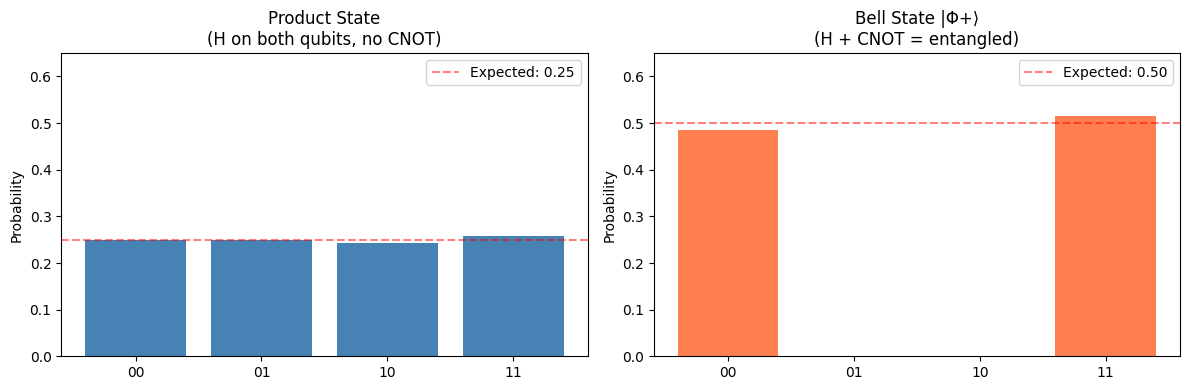

Figure saved to results/figures/w1_product_vs_bell.png


In [8]:
# Side-by-side histogram comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels = ['00', '01', '10', '11']

# Product state
product_vals = [counts_product.get(l, 0) / 4096 for l in labels]
ax1.bar(labels, product_vals, color='steelblue')
ax1.set_title('Product State\n(H on both qubits, no CNOT)')
ax1.set_ylabel('Probability')
ax1.set_ylim(0, 0.65)
ax1.axhline(y=0.25, color='red', linestyle='--', alpha=0.5, label='Expected: 0.25')
ax1.legend()

# Bell state
bell_vals = [counts.get(l, 0) / 4096 for l in labels]
ax2.bar(labels, bell_vals, color='coral')
ax2.set_title('Bell State |Φ+⟩\n(H + CNOT = entangled)')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 0.65)
ax2.axhline(y=0.50, color='red', linestyle='--', alpha=0.5, label='Expected: 0.50')
ax2.legend()

plt.tight_layout()
fig.savefig('../results/figures/w1_product_vs_bell.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/figures/w1_product_vs_bell.png")

## 1.4 All Four Bell States

There are four maximally entangled 2-qubit states (the Bell basis):

| State | Formula | Circuit modification |
|-------|---------|---------------------|
| \|Φ+⟩ | (\|00⟩ + \|11⟩)/√2 | H + CNOT (what we built) |
| \|Φ-⟩ | (\|00⟩ - \|11⟩)/√2 | H + CNOT + Z on qubit 0 |
| \|Ψ+⟩ | (\|01⟩ + \|10⟩)/√2 | H + CNOT + X on qubit 1 |
| \|Ψ-⟩ | (\|01⟩ - \|10⟩)/√2 | X on qubit 1 + H + CNOT + Z on qubit 0 |

The singlet state from QM (opposite spins) is |Ψ-⟩. Let's build all four.

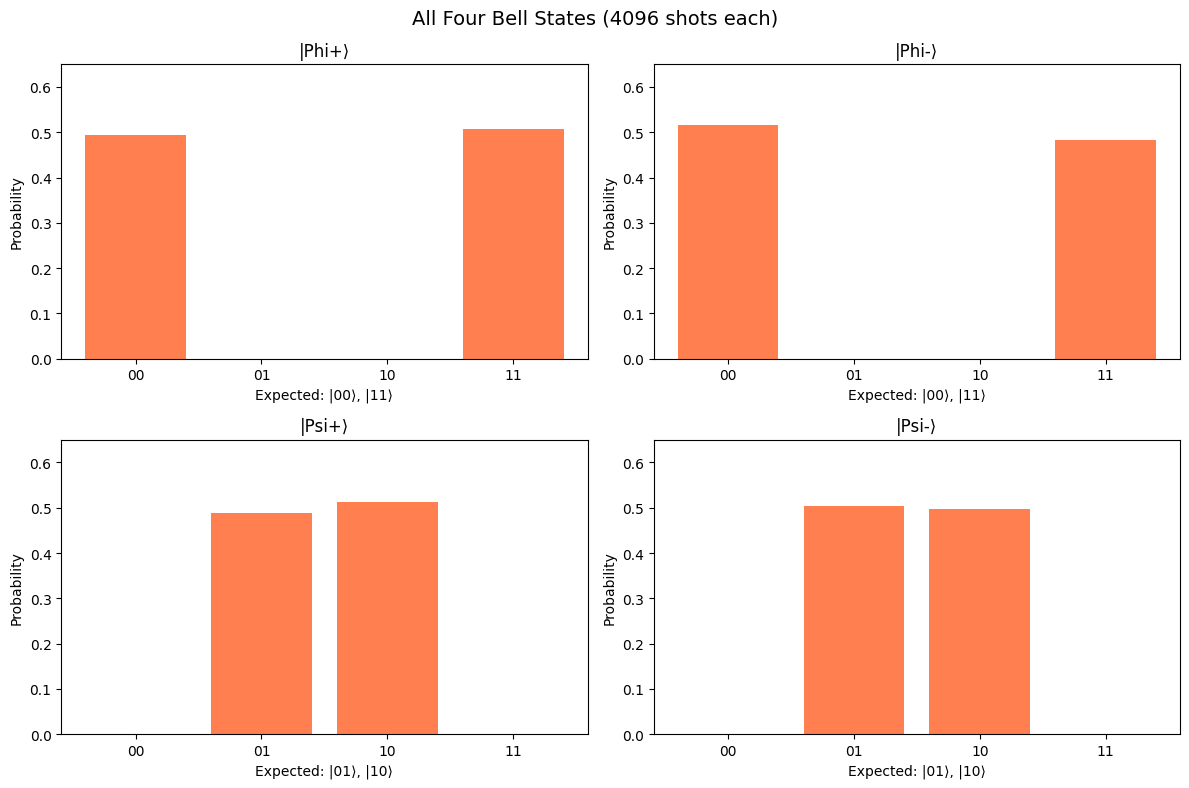

Figure saved to results/figures/w1_all_bell_states.png


In [9]:
def make_bell_state(name):
    """Build a circuit for the specified Bell state."""
    qc = QuantumCircuit(2, 2)
    
    if name == 'Phi+':
        # (|00> + |11>) / sqrt(2)
        qc.h(0)
        qc.cx(0, 1)
    elif name == 'Phi-':
        # (|00> - |11>) / sqrt(2)
        qc.h(0)
        qc.cx(0, 1)
        qc.z(0)
    elif name == 'Psi+':
        # (|01> + |10>) / sqrt(2)
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
    elif name == 'Psi-':
        # (|01> - |10>) / sqrt(2)  — the singlet state
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)
    
    qc.measure([0, 1], [0, 1])
    return qc


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
bell_names = ['Phi+', 'Phi-', 'Psi+', 'Psi-']
expected = {
    'Phi+': {'00': 0.5, '11': 0.5},
    'Phi-': {'00': 0.5, '11': 0.5},   # Z only changes phase, not measurement probabilities
    'Psi+': {'01': 0.5, '10': 0.5},
    'Psi-': {'01': 0.5, '10': 0.5},
}

for ax, name in zip(axes.flat, bell_names):
    qc = make_bell_state(name)
    result = sim.run(qc, shots=4096).result()
    counts = result.get_counts()
    
    vals = [counts.get(l, 0) / 4096 for l in labels]
    colors = ['coral' if counts.get(l, 0) > 100 else 'lightgray' for l in labels]
    ax.bar(labels, vals, color=colors)
    ax.set_title(f'|{name}⟩')
    ax.set_ylim(0, 0.65)
    ax.set_ylabel('Probability')
    
    exp_str = ', '.join(f'|{k}⟩' for k in expected[name])
    ax.set_xlabel(f'Expected: {exp_str}')

plt.suptitle('All Four Bell States (4096 shots each)', fontsize=14)
plt.tight_layout()
fig.savefig('../results/figures/w1_all_bell_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/figures/w1_all_bell_states.png")

## 1.5 Why This Matters for Shor's Algorithm

The Bell state experiment demonstrates the three ingredients Shor's algorithm needs:

1. **Superposition** (H gate): Shor's uses Hadamard gates to create a superposition of all possible inputs to the modular exponentiation function, exploring 2^n values simultaneously.

2. **Entanglement** (CNOT): Shor's entangles an input register with an output register through controlled modular exponentiation. This encodes the periodic structure of f(x) = a^x mod N into the quantum state.

3. **Interference** (measurement patterns): The Quantum Fourier Transform (Week 2) uses interference to amplify states whose frequencies match the period, so that measurement yields the period with high probability.

The Bell state is the simplest circuit that uses all the same building blocks (H, controlled operations, measurement) that Shor's algorithm uses at scale.

**Next**: Week 2 — Building the Quantum Fourier Transform from scratch.